In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import joblib

file_path = "/content/drive/MyDrive/Enterprise_NIDS/UNSW_NB15_training-set.csv"
Intrusion = pd.read_csv(file_path)

file_path = "/content/drive/MyDrive/Enterprise_NIDS/UNSW_NB15_test_split.csv"
Intrusion_test = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(Intrusion.shape)

lgb_path = '/content/drive/MyDrive/Enterprise_NIDS/Multiclass_lightgbm_model.pkl'
label_path = '/content/drive/MyDrive/Enterprise_NIDS/label_encoder.pkl'
model=joblib.load(lgb_path)
label_encoder=joblib.load(label_path)

catboost_path = '/content/drive/MyDrive/Enterprise_NIDS/catboost_model.pkl'
catboost_model = joblib.load(catboost_path)
print("CatBoost Model loaded successfully")

Dataset loaded successfully!
(175341, 45)
CatBoost Model loaded successfully


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import files

Intrusion.drop_duplicates(inplace=True)
missing_values = Intrusion.isnull().sum().sum()
print("No. of missing values = ", missing_values)

if "id" in Intrusion.columns:
    Intrusion.drop(columns=["id"], inplace=True)

half_point = len(Intrusion.columns) // 2
first_half = Intrusion.columns[:half_point]

for col in first_half:
    if pd.api.types.is_numeric_dtype(Intrusion[col]):
        Intrusion[col] = pd.to_numeric(Intrusion[col], errors="coerce")
        Intrusion[col] = Intrusion[col].fillna(Intrusion[col].median())

categorial_cols = ["proto", "service", "state"]
for col in categorial_cols:
    Intrusion[col] = Intrusion[col].fillna("missing").astype("category")

X = Intrusion.drop(columns=["attack_cat", "label"])
y_raw = Intrusion["attack_cat"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")


train_df = X_train.copy()
train_df["attack_cat"] = label_encoder.inverse_transform(y_train)
train_file_name = "UNSW_NB15_train_split.csv"
train_df.to_csv(train_file_name, index=False)

test_df = X_test.copy()
test_df["attack_cat"] = label_encoder.inverse_transform(y_test)
test_file_name = "UNSW_NB15_test_split.csv"
test_df.to_csv(test_file_name, index=False)

No. of missing values =  0
Features shape: (140272, 42)
Labels shape: (140272,)


Hyperparameter tuning:
Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100}

Test accuracy: 0.8267

Classification Report:
                precision    recall  f1-score   support

      Analysis       0.59      0.12      0.21       400
      Backdoor       0.83      0.11      0.20       349
           DoS       0.49      0.06      0.11      2453
      Exploits       0.62      0.94      0.74      6679
       Fuzzers       0.74      0.72      0.73      3637
       Generic       1.00      0.98      0.99      8000
        Normal       0.93      0.92      0.92     11200
Reconnaissance       0.92      0.74      0.82      2098
     Shellcode       0.68      0.69      0.68       227
         Worms       0.18      0.46      0.26        26

      accuracy                           0.83     35069
     macro avg       0.70      0.58      0.57     35069
  weighted avg       0.83      0.83      0.80     35069



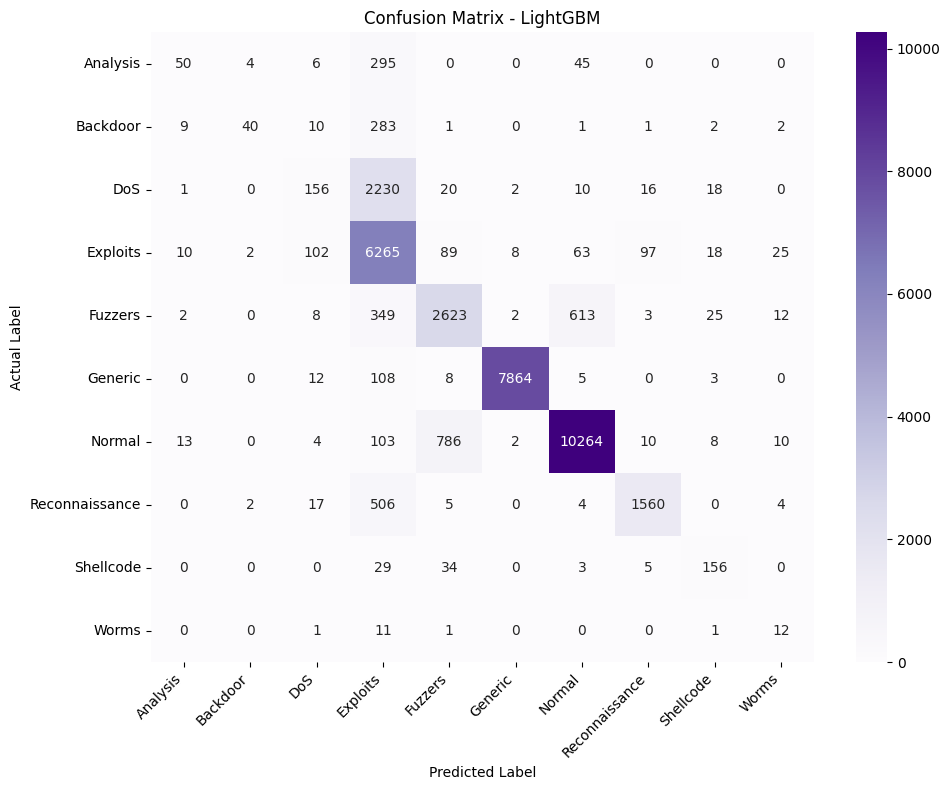

['label_encoder.pkl']

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import joblib
import seaborn as sns
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

print("Hyperparameter tuning:")
lgb_model=lgb.LGBMClassifier(random_state=42,verbose=-1)
param_grid={
    "n_estimators":[50,100],
    "learning_rate":[0.05,0.1],
    "max_depth":[5,7]
}
grid_search=GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model=grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")
y_pred = best_model.predict(X_test)
accuracy=accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - LightGBM")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
joblib.dump(best_model, "Multiclass_lightgbm_model.pkl")
joblib.dump(label_encoder,"label_encoder.pkl")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Normal', 'Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']))

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

cat_features = ['proto', 'service', 'state']

cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

y_pred_cat = cat_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_cat))

print(
    classification_report(
        y_test,
        y_pred_cat,
        target_names=class_names
    )
)

In [ ]:
import joblib
joblib.dump(cat_model, "catboost_model.pkl")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

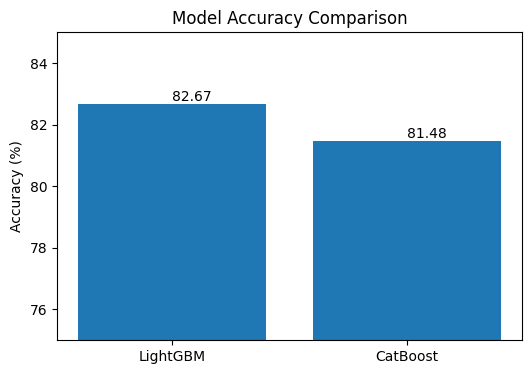

In [ ]:
import matplotlib.pyplot as plt

models = ['LightGBM', 'CatBoost']
accuracies = [82.67, 81.48]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(75, 85)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, str(v))

plt.show()

In [ ]:
%%writefile stream_dashboard_feed.py
import time
import joblib
import pandas as pd

try:
  print("Model and label encoder successfully loaded.")
except FileNotFoundError:
  print("Error: Could not find 'multiclass_lightgbm_model.pkl' or 'label_encoder.pkl'.")
  print("Run your training script first to generate these files.")
  exit()

if "id" in Intrusion_test.columns:
  Intrusion_test.drop(columns=["id"],inplace=True)
X_stream_source=Intrusion_test.drop(columns=["attack_cat","label"],errors="ignore")
ground_truth=Intrusion_test["attack_cat"]
categorial_cols=["proto","service","state"]
for col in categorial_cols:
  X_stream_source[col]=(
      X_stream_source[col].astype(str).fillna("missing").astype("category")
  )
def network_packet_stream (delay_seconds=1.0):
    print(f"\nStarting Stream (Interval :{delay_seconds}s) Control+c to stop")
    for index in range(min(600, len(X_stream_source))):
      packet_row=X_stream_source.iloc[[index]]
      actual_attack_name=ground_truth.iloc[index]
      numeric_pred=model.predict(packet_row)[0]
      predicted_attack_name=label_encoder.inverse_transform([numeric_pred])[0]

      dashboard_payload={
          "packet_id":index,
          "protocol":packet_row["proto"].values[0],
          "service":packet_row["service"].values[0],
          "duration":float(packet_row["dur"].values[0]),
          "source_bytes":int(packet_row["sbytes"].values[0]),
          "destination_bytes":int(packet_row["dbytes"].values[0]),
          "predicted_status":predicted_attack_name,
          "actual_status":actual_attack_name,
          "alert_triggered": "SAFE"
          if predicted_attack_name=="Normal"
          else "Alert"
      }
      yield dashboard_payload
      time.sleep(delay_seconds)
if __name__=="__main__":
  for packet in network_packet_stream(delay_seconds=0.1):
    print(
        f"[{packet['alert_triggered']}] Packet ID: {packet['packet_id']} | "
        f"Proto: {packet['protocol']} | Dur : {packet['duration']}s | "
        f"Predicted: {packet['predicted_status']} (Actual: {packet['actual_status']})"
    )

Writing stream_dashboard_feed.py


In [ ]:
print(Intrusion.columns.tolist())
print(Intrusion[['attack_cat']].head())

['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
  attack_cat
0     Normal
1     Normal
2     Normal
3     Normal
4     Normal


In [ ]:
total_traffic = len(Intrusion)

normal_count = (Intrusion["attack_cat"] == "Normal").sum()

attack_count = total_traffic - normal_count

print("Total Traffic:", total_traffic)
print("Normal Traffic:", normal_count)
print("Attacks:", attack_count)

Total Traffic: 175341
Normal Traffic: 56000
Attacks: 119341


In [ ]:
attack_distribution = Intrusion["attack_cat"].value_counts()
print(attack_distribution)

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:
import plotly.express as px

fig = px.bar(
    x=attack_distribution.index,
    y=attack_distribution.values,
    labels={"x":"Attack Type","y":"Count"},
    title="Attack Distribution - UNSW NB15"
)

fig.show()

In [ ]:
lightgbm_acc = 82.67
catboost_acc = 81.48
print(lightgbm_acc, catboost_acc)

82.67 81.48


In [ ]:
print("Total Traffic:", total_traffic)
print("Normal Traffic:", normal_count)
print("Attacks:", attack_count)
print(attack_distribution)

Total Traffic: 175341
Normal Traffic: 56000
Attacks: 119341
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64
